# Comparaison des modèles

## Modèles Machine Learning

Ces deux premières figures ne portent que sur les **baselines Machine Learning** (régression logistique, KNN, SVM, Random Forest, XGBoost) — pour la partie « machine learning seule » du rapport. Les modèles deep learning sont comparés dans les sections suivantes.

In [ ]:
df.plot(kind='barh', x='modele', y='f1_macro', legend=False, figsize=(9, 6))
plt.gca().invert_yaxis()
plt.xlabel('F1-macro')
plt.ylabel('')
plt.title('Comparaison des modèles Machine Learning — F1-macro (test)')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/rpt_f1_ml.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
metrics = ['f1_covid', 'f1_normal', 'f1_lung_opacity', 'f1_viral_pneumonia']
df.set_index('modele')[metrics].plot(kind='barh', figsize=(10, 9))
plt.gca().invert_yaxis()
plt.xlabel('F1-score')
plt.ylabel('')
plt.title('F1-score par classe et par modèle — Machine Learning')
plt.legend(title='Classe')
plt.tight_layout()
plt.savefig('../reports/figures/rpt_perclass_ml.png', dpi=130, bbox_inches='tight')
plt.show()

## Comparaison par F1-macro

Le F1-macro (moyenne non pondérée des F1 par classe) est notre métrique de référence : contrairement à l'accuracy, il ne se laisse pas tirer vers le haut par la classe majoritaire (Normal), et pénalise un modèle qui rate une classe minoritaire comme COVID.

On consolide ici **tous les modèles** dans un seul tableau :

- ceux déjà présents dans `model_comparison.csv` (baselines ML + CNN « niveaux » + inception V3 + VGG16) ;
- les modèles deep learning restants, lus dans les notebooks de chaque dossier — **F1-macro sur le test** (support 2084) : `CNN v1 (from scratch)`, `EfficientNet`, les 4 variantes `ResNet` (score après fine-tuning), et `CovidNet`.

> *CovidNet ne calcule dans son notebook qu'un F1 pondéré (weighted) ; son F1-macro (0,83) a été **recalculé à partir de sa matrice de confusion sur le test** — le F1 weighted correspondant retombe bien sur 0,846, ce qui valide la reconstruction.*

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Table maître (baselines ML + CNN niveaux + inception + VGG16) ---
data = pd.read_csv("model_comparison.csv")
# coercition numérique robuste (au cas où le CSV utilise la virgule décimale)
for c in ["accuracy", "f1_macro", "f1_covid", "f1_normal", "f1_lung_opacity", "f1_viral_pneumonia"]:
    data[c] = pd.to_numeric(data[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")

# --- Modèles deep learning restants, lus dans les notebooks de chaque dossier ---
# F1-macro sur le jeu de test (support 2084). ResNet = score après fine-tuning.
ajouts_dl = pd.DataFrame([
    {"modele": "CNN v1 (from scratch)",    "f1_macro": 0.79},   # cnn_v1_maxime.ipynb
    {"modele": "EfficientNet",             "f1_macro": 0.82},   # EfficientNet/EfficientNet.ipynb
    {"modele": "ResNet50 (balanced)",      "f1_macro": 0.875},  # ResNet/ResNet_50.ipynb
    {"modele": "ResNet50 (unbalanced)",    "f1_macro": 0.876},  # ResNet/ResNet_50_unbalanced.ipynb
    {"modele": "ResNet101V2 (balanced)",   "f1_macro": 0.877},  # ResNet/ResNet101V2.ipynb
    {"modele": "ResNet101V2 (unbalanced)", "f1_macro": 0.873},  # ResNet/ResNet101V2_unbalanced.ipynb
    {"modele": "DenseNet",                 "f1_macro": 0.918},  # calculé depuis y_prob/y_true (DenseNet/)
    {"modele": "CovidNet",                 "f1_macro": 0.840},  # calculé depuis y_prob/y_true V1 (CovidNet_1/predictions/V1/)
])
data = pd.concat([data, ajouts_dl], ignore_index=True)

# --- Étiquette ML vs Deep Learning (par mot-clé dans le nom du modèle) ---
EST_DL = re.compile(r"CNN|inception|VGG|ResNet|EfficientNet|CovidNet", re.I)
data["type"] = data["modele"].apply(
    lambda m: "Deep Learning" if EST_DL.search(m) else "Machine Learning"
)

# --- Palette daltonien-safe (Okabe-Ito) et helper de tracé ---
BLEU, ORANGE, INK = "#0072B2", "#E69F00", "#222222"

def barh_f1(sub, couleurs, titre, figsize, fs_label=9):
    """Barres horizontales de f1_macro, triées, avec valeur en bout de barre."""
    sub = sub.sort_values("f1_macro").reset_index(drop=True)
    y = np.arange(len(sub))
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(y, sub["f1_macro"], color=couleurs(sub), height=0.72, zorder=3)
    for yi, v in zip(y, sub["f1_macro"]):
        ax.text(v + 0.008, yi, f"{v:.2f}", va="center", ha="left", fontsize=fs_label, color=INK)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["modele"])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("F1-macro (test)")
    ax.set_title(titre, fontsize=12, fontweight="bold")
    ax.grid(axis="x", color="#cccccc", lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    return fig, ax

print(f"{len(data)} modèles  —  "
      f"{(data.type=='Deep Learning').sum()} deep learning, "
      f"{(data.type=='Machine Learning').sum()} machine learning")
data[["modele", "type", "f1_macro"]].sort_values("f1_macro", ascending=False)

33 modèles  —  20 deep learning, 13 machine learning


,modele,type,f1_macro
15,CNN 4 couches,Deep Learning,0.920
22,CNN 5 couches,Deep Learning,0.920
18,CNN 3 couches,Deep Learning,0.910
16,CNN 3 couches (L2+W),Deep Learning,0.910
14,CNN 4 couches (L2),Deep Learning,0.910
17,CNN 3 couches (L2),Deep Learning,0.910
21,VGG16,Deep Learning,0.910
23,CNN 6 couches,Deep Learning,0.910
24,CNN 4 couches (tuned),Deep Learning,0.900
13,CNN 4 couches (L2+W),Deep Learning,0.900


### F1-macro — modèles Deep Learning uniquement

Comparaison entre nos modèles deep learning seuls (CNN maison, transfer learning : VGG16, inception, ResNet, EfficientNet).

In [ ]:
dl = data[data["type"] == "Deep Learning"]

barh_f1(dl, lambda s: BLEU,
        "F1-macro — modèles Deep Learning", figsize=(9, 7))
plt.tight_layout()
plt.savefig('../reports/figures/rpt_f1_dl.png', dpi=130, bbox_inches='tight')
plt.show()

### F1-macro — comparaison globale Machine Learning vs Deep Learning

Tous les modèles sur une même figure, colorés par famille. On voit nettement le bloc deep learning (bleu) se détacher au-dessus des baselines de machine learning (orange).

In [ ]:
fig, ax = barh_f1(
    data,
    lambda s: s["type"].map({"Deep Learning": BLEU, "Machine Learning": ORANGE}).values,
    "F1-macro — comparaison Machine Learning vs Deep Learning",
    figsize=(10, 10), fs_label=8,
)
ax.legend(
    handles=[Patch(color=BLEU, label="Deep Learning"),
             Patch(color=ORANGE, label="Machine Learning")],
    loc="lower right", frameon=False,
)
plt.tight_layout()
plt.savefig('../reports/figures/rpt_f1_global.png', dpi=130, bbox_inches='tight')
plt.show()

## F1-macro par époque

Planche des courbes F1-macro (entraînement vs validation) par époque, assemblées depuis les PNG déjà sauvegardés (aucun modèle réexécuté). Sont inclus tous les modèles disposant d'une courbe : les **CNN** (32 → 1024, dont *256 tuned*), **inception V3**, **VGG16**, et les **4 ResNet** (courbes fournies par Noura).

*Absents (pas de courbe F1/époque) : CNN v1 (from scratch), EfficientNet, CovidNet.*

figure sauvegardée -> reports/figures/f1_par_epoque.png


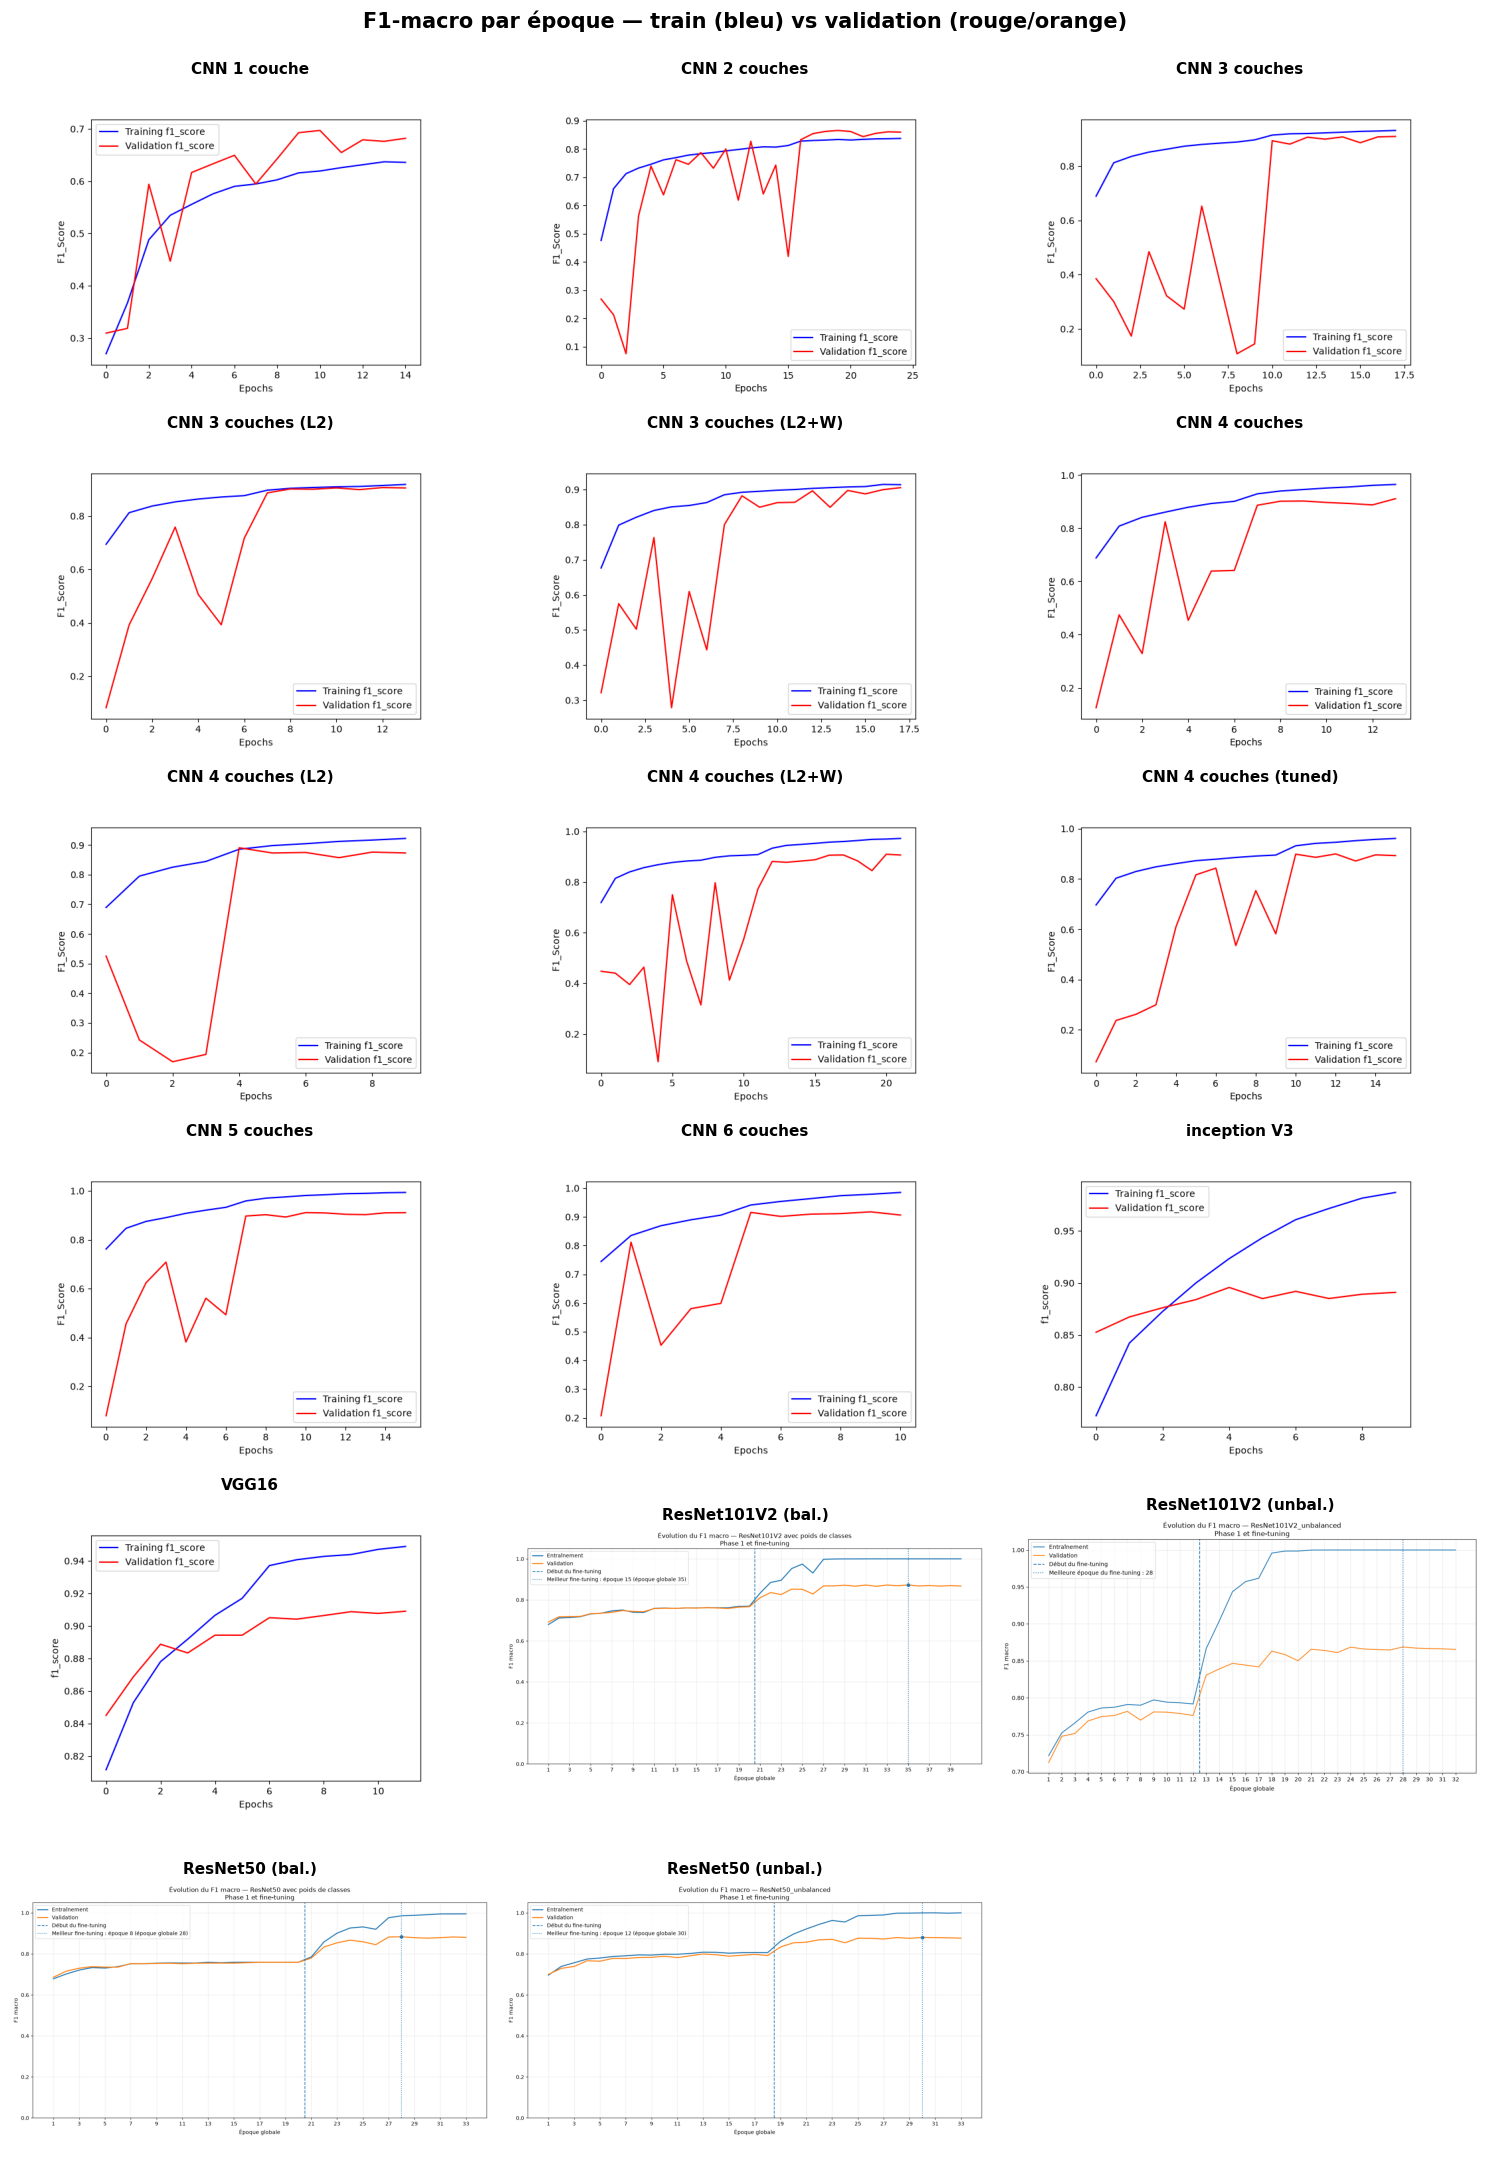

In [6]:
import os
import matplotlib.image as mpimg

# (nom affiché, PNG relatif au dossier models/) — modèles avec une courbe F1/époque
figs_epoque = [
    ("CNN 1 couche",          "cnn32/cnn_32.png"),
    ("CNN 2 couches",          "cnn64/cnn_64.png"),
    ("CNN 3 couches",         "cnn128/cnn_128.png"),
    ("CNN 3 couches (L2)",    "cnn128/cnn_128_l2.png"),
    ("CNN 3 couches (L2+W)",  "cnn128/cnn_128_l2_weight.png"),
    ("CNN 4 couches",         "cnn256/cnn_256.png"),
    ("CNN 4 couches (L2)",    "cnn256/cnn_256_l2.png"),
    ("CNN 4 couches (L2+W)",  "cnn256/cnn_256_l2_weight.png"),
    ("CNN 4 couches (tuned)", "cnn256_tuned/cnn_256.png"),
    ("CNN 5 couches",         "cnn512/cnn_512.png"),
    ("CNN 6 couches",        "cnn1024/cnn_1024.png"),
    ("inception V3",    "inceptionv3/inceptionv3.png"),
    ("VGG16",           "vgg16/vgg16.png"),
    ("ResNet101V2 (bal.)",   "../reports/figures/f1ep_resnet101_bal.png"),
    ("ResNet101V2 (unbal.)", "../reports/figures/f1ep_resnet101_unbal.png"),
    ("ResNet50 (bal.)",      "../reports/figures/f1ep_resnet50_bal.png"),
    ("ResNet50 (unbal.)",    "../reports/figures/f1ep_resnet50_unbal.png"),
]

ncols = 3
nrows = int(np.ceil(len(figs_epoque) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.7 * nrows))
for ax, (titre, path) in zip(axes.flat, figs_epoque):
    ax.imshow(mpimg.imread(path))
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.axis('off')
for ax in axes.flat[len(figs_epoque):]:
    ax.axis('off')

fig.suptitle('F1-macro par époque — train (bleu) vs validation (rouge/orange)', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
os.makedirs('../reports/figures', exist_ok=True)
fig.savefig('../reports/figures/f1_par_epoque.png', dpi=105, bbox_inches='tight')
print('figure sauvegardée -> reports/figures/f1_par_epoque.png')
plt.show()

## Matrices de confusion — Machine Learning vs Deep Learning

Matrices de confusion sur le **jeu de test** (2084 images), une figure par famille. Les effectifs ont été **relevés dans les notebooks de chaque modèle** (sorties texte ou heatmaps annotées), puis re-tracés ici en style uniforme. Chaque vignette affiche l'accuracy et le F1-macro **recalculés à partir de la matrice** — donc cohérents avec elle.

Chaque matrice a été validée par ses sommes de lignes = effectifs réels du test par classe : COVID 337, Lung_Opacity 599, Normal 1014, Viral Pneumonia 134.

> ⚠️ **Incohérence à trancher — SVM.** Le F1-macro recalculé depuis la matrice du SVM disponible (`svm_weighted`) vaut **0,47**, alors que `model_comparison.csv` annonce **0,62** pour « SVM (GridSearch best) ». Aucune matrice de confusion sauvegardée ne correspond à 0,62 (les notebooks SVM donnent 0,45–0,47). À vérifier : soit la valeur 0,62 de la table est à corriger, soit la matrice du bon SVM n'a pas été sauvegardée.

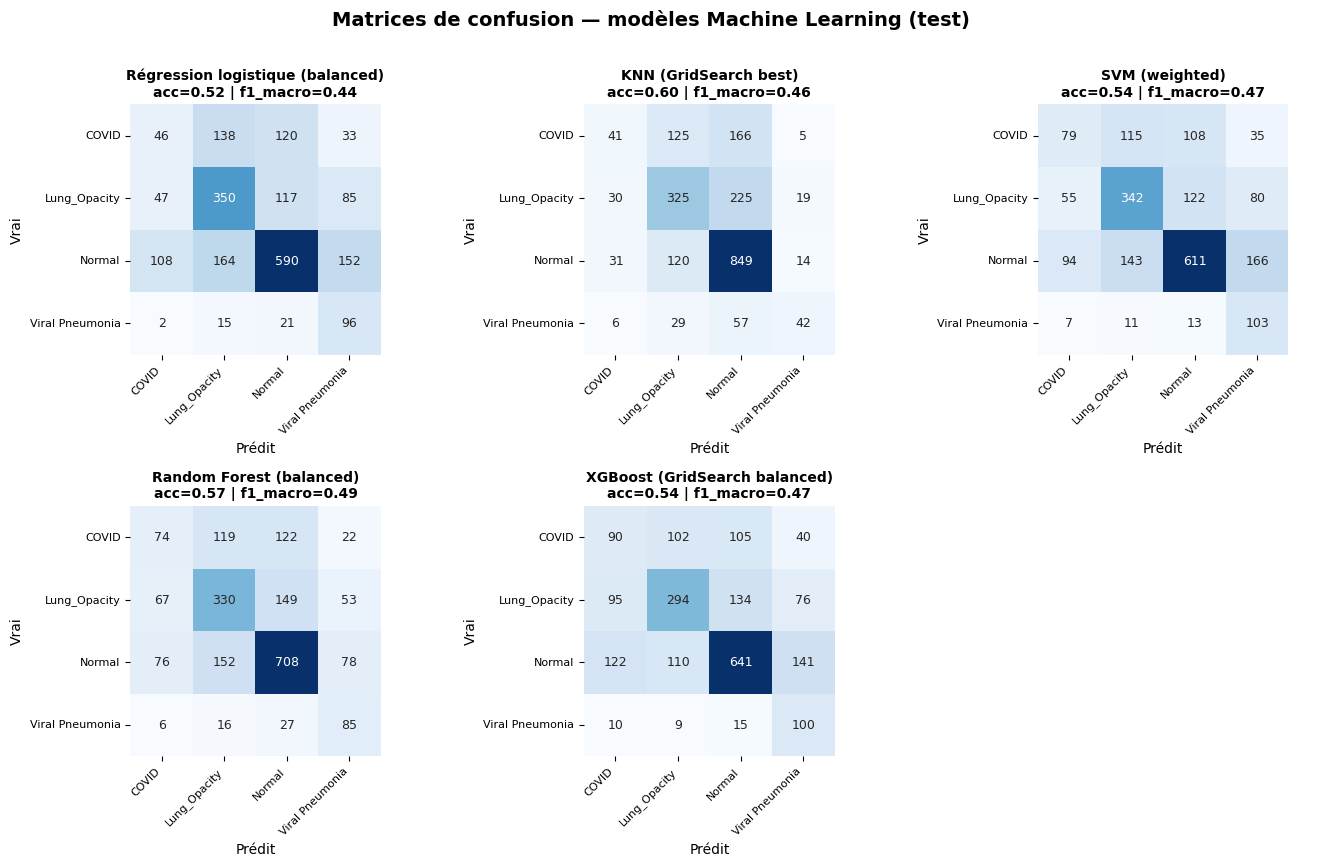

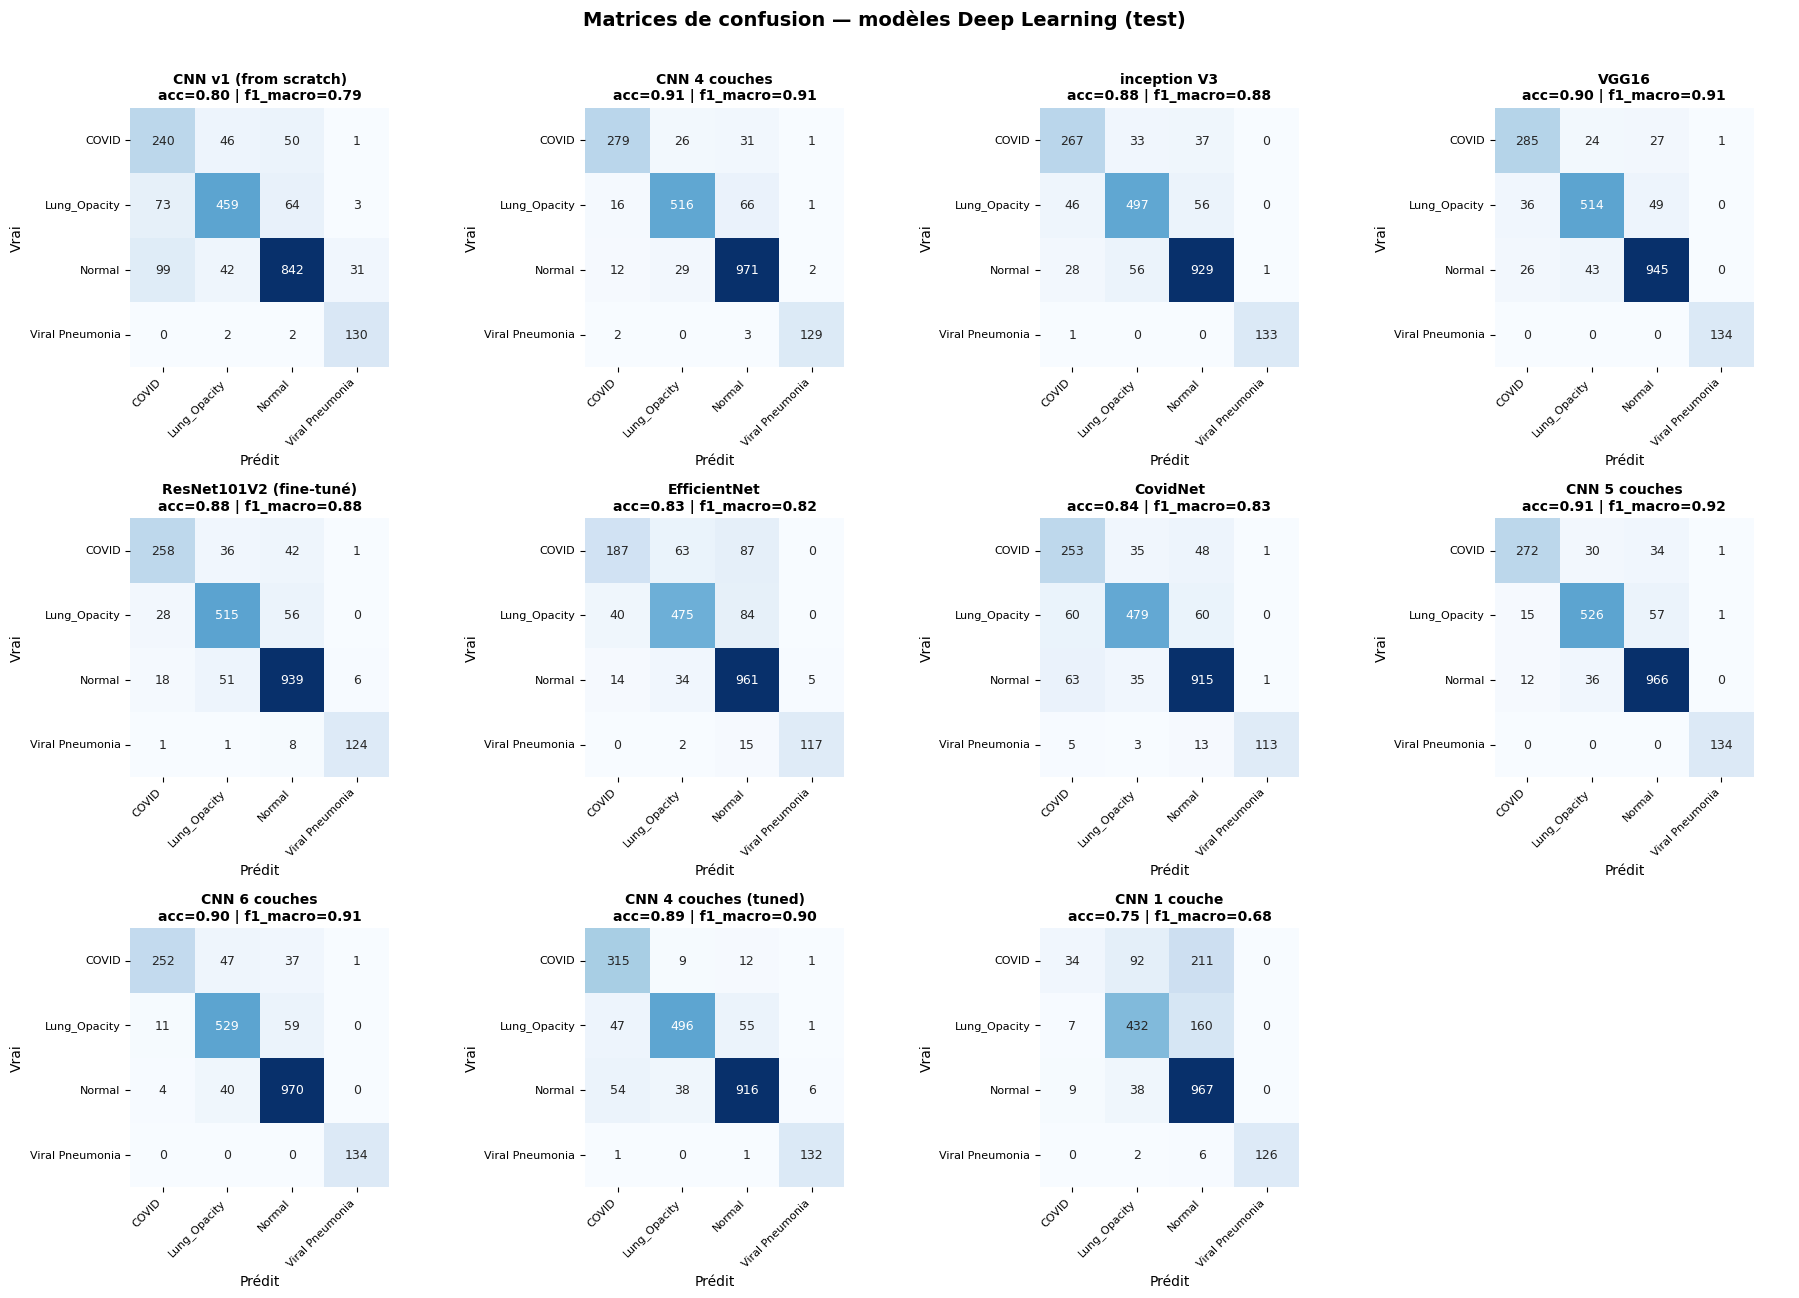

figures sauvegardées -> reports/figures/cm_machine_learning.png, cm_deep_learning.png


In [7]:
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

CLASSES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

# Matrices de confusion sur le TEST (lignes = vrai, colonnes = prédit),
# relevées dans le notebook de chaque modèle. type = "ML" ou "DL".
CM = {
    "Régression logistique (balanced)": ("ML", [[46, 138, 120, 33], [47, 350, 117, 85], [108, 164, 590, 152], [2, 15, 21, 96]]),
    "KNN (GridSearch best)":            ("ML", [[41, 125, 166, 5], [30, 325, 225, 19], [31, 120, 849, 14], [6, 29, 57, 42]]),
    "SVM (weighted)":                   ("ML", [[79, 115, 108, 35], [55, 342, 122, 80], [94, 143, 611, 166], [7, 11, 13, 103]]),
    "Random Forest (balanced)":         ("ML", [[74, 119, 122, 22], [67, 330, 149, 53], [76, 152, 708, 78], [6, 16, 27, 85]]),
    "XGBoost (GridSearch balanced)":    ("ML", [[90, 102, 105, 40], [95, 294, 134, 76], [122, 110, 641, 141], [10, 9, 15, 100]]),
    "CNN v1 (from scratch)":            ("DL", [[240, 46, 50, 1], [73, 459, 64, 3], [99, 42, 842, 31], [0, 2, 2, 130]]),
    "CNN 4 couches":                          ("DL", [[279, 26, 31, 1], [16, 516, 66, 1], [12, 29, 971, 2], [2, 0, 3, 129]]),
    "inception V3":                     ("DL", [[267, 33, 37, 0], [46, 497, 56, 0], [28, 56, 929, 1], [1, 0, 0, 133]]),
    "VGG16":                            ("DL", [[285, 24, 27, 1], [36, 514, 49, 0], [26, 43, 945, 0], [0, 0, 0, 134]]),
    "ResNet101V2 (fine-tuné)":          ("DL", [[258, 36, 42, 1], [28, 515, 56, 0], [18, 51, 939, 6], [1, 1, 8, 124]]),
    "EfficientNet":                     ("DL", [[187, 63, 87, 0], [40, 475, 84, 0], [14, 34, 961, 5], [0, 2, 15, 117]]),
    "DenseNet":                         ("DL", [[280, 25, 31, 1], [23, 511, 65, 0], [11, 28, 975, 0], [0, 0, 0, 134]]),
    "CovidNet":                         ("DL", [[208, 70, 58, 1], [19, 532, 47, 1], [37, 53, 922, 2], [0, 5, 11, 118]]),
    "CNN 5 couches":                          ("DL", [[272, 30, 34, 1], [15, 526, 57, 1], [12, 36, 966, 0], [0, 0, 0, 134]]),
    "CNN 6 couches":                         ("DL", [[252, 47, 37, 1], [11, 529, 59, 0], [4, 40, 970, 0], [0, 0, 0, 134]]),
    "CNN 4 couches (tuned)":                  ("DL", [[315, 9, 12, 1], [47, 496, 55, 1], [54, 38, 916, 6], [1, 0, 1, 132]]),
    "CNN 1 couche":                           ("DL", [[34, 92, 211, 0], [7, 432, 160, 0], [9, 38, 967, 0], [0, 2, 6, 126]]),
}

SUPPORTS = [337, 599, 1014, 134]  # effectifs test par classe -> contrôle des sommes de lignes


def _metrics_from_cm(cm):
    """Reconstruit (y_true, y_pred) depuis la matrice pour recalculer acc et f1_macro."""
    cm = np.asarray(cm)
    y_true, y_pred = [], []
    for i in range(4):
        for j in range(4):
            y_true += [i] * cm[i, j]
            y_pred += [j] * cm[i, j]
    return accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro")


def figure_cm(famille, titre, ncols, fichier_png):
    noms = [k for k, (typ, _) in CM.items() if typ == famille]
    n = len(noms)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.4 * nrows))
    axes = np.asarray(axes).reshape(-1)
    for ax, nom in zip(axes, noms):
        cm = np.asarray(CM[nom][1])
        assert list(cm.sum(axis=1)) == SUPPORTS, f"sommes de lignes inattendues pour {nom}"
        acc, f1 = _metrics_from_cm(cm)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, annot_kws={"size": 9})
        ax.set_title(f"{nom}\nacc={acc:.2f} | f1_macro={f1:.2f}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Prédit")
        ax.set_ylabel("Vrai")
        ax.tick_params(labelsize=8)
        for t in ax.get_xticklabels():
            t.set_rotation(45)
            t.set_ha("right")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titre, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    os.makedirs("../reports/figures", exist_ok=True)
    fig.savefig(f"../reports/figures/{fichier_png}", dpi=115, bbox_inches="tight")
    plt.show()


figure_cm("ML", "Matrices de confusion — modèles Machine Learning (test)", 3, "cm_machine_learning.png")
figure_cm("DL", "Matrices de confusion — modèles Deep Learning (test)", 4, "cm_deep_learning.png")
print("figures sauvegardées -> reports/figures/cm_machine_learning.png, cm_deep_learning.png")

### F1-score par classe et par modèle — Deep Learning

Équivalent, pour le deep learning, de la figure « F1-score par classe » des baselines ML. Le F1 par classe est **recalculé à partir des matrices de confusion** ci-dessus (mêmes modèles), ce qui permet d'inclure EfficientNet, ResNet et CovidNet — absents des colonnes par classe du CSV. Les modèles sont triés par F1 moyen.

In [ ]:
def _f1_par_classe(cm):
    """F1 par classe recalculé depuis une matrice de confusion 4x4."""
    cm = np.asarray(cm)
    y_true, y_pred = [], []
    for i in range(4):
        for j in range(4):
            y_true += [i] * cm[i, j]
            y_pred += [j] * cm[i, j]
    return f1_score(y_true, y_pred, average=None)

dl_perclass = {nom: _f1_par_classe(cm) for nom, (typ, cm) in CM.items() if typ == "DL"}
perclass_df = pd.DataFrame(dl_perclass, index=CLASSES).T
perclass_df = perclass_df.loc[perclass_df.mean(axis=1).sort_values().index]

perclass_df.plot(kind="barh", figsize=(11, 9))
plt.xlabel("F1-score")
plt.ylabel("")
plt.title("F1-score par classe et par modèle — Deep Learning")
plt.legend(title="Classe")
plt.tight_layout()
plt.savefig('../reports/figures/rpt_perclass_dl.png', dpi=130, bbox_inches='tight')
plt.show()

## Courbes Précision-Rappel et importance des features — Modèles Machine Learning

Les modèles ML sont ré-entraînés ici depuis les CSV de features (`csv/train_features.csv` / `csv/test_features.csv`) pour obtenir les probabilités brutes nécessaires aux vraies courbes PR.

**Courbes PR** : pour chaque classe (One-vs-Rest), on fait varier le seuil de décision → on obtient une courbe complète avec l'AP (Average Precision = aire sous la courbe).

**Feature importance** : quelles features (`lum_interieur_masque`, `lum_exterieur_masque`, `surface_masque`, `variance_laplacien`) influencent le plus la décision, par modèle.

In [ ]:
import warnings
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')

# ── Données ──
train_df = pd.read_csv('../csv/train_features.csv')
test_df  = pd.read_csv('../csv/test_features.csv')

FEAT_COLS = ['lum_interieur_masque', 'lum_exterieur_masque', 'surface_masque', 'variance_laplacien']
CLASS_ORDER = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
CLASS_MAP   = {c: i for i, c in enumerate(CLASS_ORDER)}

X_train = train_df[FEAT_COLS].values
y_train = train_df['classe'].map(CLASS_MAP).values
X_test  = test_df[FEAT_COLS].values
y_test  = test_df['classe'].map(CLASS_MAP).values
y_test_bin = label_binarize(y_test, classes=list(range(4)))

# ── Modèles ML ──
MODELS_ML = {
    'Régression logistique': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'KNN':                   KNeighborsClassifier(n_neighbors=5),
    'SVM':                   SVC(probability=True, class_weight='balanced', kernel='rbf', random_state=42),
    'Random Forest':         RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
    'XGBoost':               XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', verbosity=0),
}

# ── Entraînement ──
clfs = {}
y_probs = {}
for nom, clf in MODELS_ML.items():
    clf.fit(X_train, y_train)
    y_probs[nom] = clf.predict_proba(X_test)
    clfs[nom] = clf
    print(f"  {nom} — entraîné ✓")

print(f"\n{len(MODELS_ML)} modèles prêts, {len(y_test)} images de test")

In [ ]:
# Courbes PR : 4 sous-figures (une par classe), 5 courbes par sous-figure (une par modèle ML)
COULEURS_ML = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00']

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (ci, classe) in zip(axes.flat, enumerate(CLASS_ORDER)):
    for (nom, y_prob), couleur in zip(y_probs.items(), COULEURS_ML):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, ci], y_prob[:, ci])
        ap = average_precision_score(y_test_bin[:, ci], y_prob[:, ci])
        ax.plot(rec, prec, color=couleur, lw=1.8, label=f"{nom} (AP={ap:.3f})")
    ax.set_xlabel('Rappel', fontsize=10)
    ax.set_ylabel('Précision', fontsize=10)
    ax.set_title(f'Classe : {classe}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7.5, loc='lower left', framealpha=0.9)
    ax.grid(True, color='#eeeeee')
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

fig.suptitle('Courbes Précision-Rappel — Modèles Machine Learning (test)', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/rpt_pr_curves_ml.png', dpi=130, bbox_inches='tight')
plt.show()
print('figure sauvegardée -> reports/figures/rpt_pr_curves_ml.png')

### Feature importance — Modèles Machine Learning

RF et XGBoost exposent directement `feature_importances_`. Pour les autres modèles (RegLog, SVM, KNN), on utilise la **permutation importance** : on permute aléatoirement les valeurs d'une feature sur le test et on mesure la chute de F1-macro — plus la chute est grande, plus la feature compte.

In [ ]:
from sklearn.inspection import permutation_importance

FEAT_LABELS = ['Lum.\nintérieur', 'Lum.\nextérieur', 'Surface\nmasque', 'Variance\nLaplacien']

# RF et XGBoost : feature_importances_ intégrée
# RegLog, SVM, KNN : permutation importance sur le test (F1-macro)
def get_importance(nom, clf):
    if hasattr(clf, 'feature_importances_'):
        return clf.feature_importances_, None
    else:
        r = permutation_importance(clf, X_test, y_test, n_repeats=10,
                                   scoring='f1_macro', random_state=42, n_jobs=-1)
        return r.importances_mean, r.importances_std

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=False)
for ax, (nom, clf), couleur in zip(axes, clfs.items(), COULEURS_ML):
    imp, std = get_importance(nom, clf)
    idx = np.argsort(imp)[::-1]
    bars = ax.bar(range(4), imp[idx], color=couleur, alpha=0.85, width=0.6)
    if std is not None:
        ax.errorbar(range(4), imp[idx], yerr=std[idx],
                    fmt='none', color='#333333', capsize=4, lw=1.2)
    ax.set_xticks(range(4))
    ax.set_xticklabels([FEAT_LABELS[i] for i in idx], fontsize=8)
    ax.set_title(nom, fontsize=9, fontweight='bold')
    ax.set_ylabel('Importance' if ax == axes[0] else '', fontsize=9)
    ax.grid(axis='y', color='#eeeeee')
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

fig.suptitle('Importance des features — Modèles Machine Learning\n'
             '(RF/XGBoost : feature_importances_ intégrée  |  Autres : permutation importance F1-macro)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/rpt_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('figure sauvegardée -> reports/figures/rpt_feature_importance.png')

## Grad-CAM par modèle

Planche comparant les cartes d'activation (Grad-CAM) : pour chaque modèle, une image originale et sa carte de chaleur, qui indique les zones sur lesquelles le modèle s'appuie pour décider. L'intérêt : vérifier que la décision repose bien sur les **champs pulmonaires** et non sur des artefacts (fond, bords, annotations).

**Couverture :**
- **CNN 4 couches** et **CNN v1 (from scratch)** : Grad-CAM régénéré ici à partir des poids `.keras` sauvegardés (une image par classe).
- **CovidNet** et **ResNet101V2** : Grad-CAM récupéré directement des sorties de leurs notebooks.
- ⚠️ **inception V3, VGG16, EfficientNet** : non disponibles — ni poids `.keras` sauvegardés, ni figure Grad-CAM dans leur notebook. À ajouter en exécutant la cellule Grad-CAM de ces notebooks (leur code existe déjà).

*Note : les figures ne sont pas parfaitement homogènes (CovidNet montre un exemple par classe, ResNet quatre cas COVID, palettes légèrement différentes) car chacune provient de son propre pipeline.*

## Courbes Précision-Rappel — Modèles Deep Learning

Les courbes PR des modèles DL sont générées depuis les fichiers `predictions/y_true_test_<modele>.npy` et `predictions/y_prob_test_<modele>.npy` sauvegardés par chaque auteur depuis son propre notebook, **après** l'appel à `model.predict()`.

**Lignes à ajouter à la fin de chaque notebook DL (une fois le modèle entraîné) :**
```python
import numpy as np, os
os.makedirs("predictions", exist_ok=True)           # dossier models/predictions/
np.save("predictions/y_true_test_cnn256.npy", y_true_test_class)   # adapter le nom
np.save("predictions/y_prob_test_cnn256.npy", test_pred)           # softmax shape (N, 4)
```
Pour les ResNet (Noura) : `y_true_phase2` / `y_prob_phase2` — même principe.

In [ ]:
import glob
from pathlib import Path

CLASS_ORDER_DL = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

def make_nom(prob_path):
    """Génère un nom lisible depuis le chemin du fichier .npy."""
    p = Path(prob_path)
    stem = p.stem.replace("y_prob_test_", "")
    for part in p.parts:
        if part in ("V1", "V2"):
            return f"{stem} ({part})"
    parent = p.parent
    while parent.name in ("predictions", "."):
        parent = parent.parent
    if "tuned" in parent.name.lower():
        return f"{stem} (tuned)"
    return stem

# Recherche récursive dans tous les sous-dossiers de models/
prob_files = sorted(glob.glob("**/y_prob_test_*.npy", recursive=True))
prob_files = [p for p in prob_files if "V2" not in p.replace("\\", "/").split("/")]

if not prob_files:
    print("Aucun fichier y_prob_test_*.npy trouvé.")
else:
    dl_preds = {}
    for prob_path in prob_files:
        nom = make_nom(prob_path)
        true_path = prob_path.replace("y_prob_test_", "y_true_test_")
        if not os.path.exists(true_path):
            print(f"  [SKIP] {nom} — y_true_test manquant")
            continue
        dl_preds[nom] = {
            "y_true": np.load(true_path),
            "y_prob": np.load(prob_path),
        }
        print(f"  {nom} — chargé ✓  shape: {dl_preds[nom]['y_prob'].shape}")

    print(f"\n→ {len(dl_preds)} modèles chargés")

    n = len(dl_preds)
    PALETTE_DL = plt.cm.tab20(np.linspace(0, 0.95, n))

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    for ax, (ci, classe) in zip(axes.flat, enumerate(CLASS_ORDER_DL)):
        for (nom, preds), couleur in zip(dl_preds.items(), PALETTE_DL):
            y_tb = label_binarize(preds["y_true"], classes=list(range(4)))
            prec, rec, _ = precision_recall_curve(y_tb[:, ci], preds["y_prob"][:, ci])
            ap = average_precision_score(y_tb[:, ci], preds["y_prob"][:, ci])
            ax.plot(rec, prec, lw=1.5, color=couleur, label=f"{nom} (AP={ap:.2f})")
        ax.set_xlabel("Rappel", fontsize=10)
        ax.set_ylabel("Précision", fontsize=10)
        ax.set_title(f"Classe : {classe}", fontsize=11, fontweight="bold")
        ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05)
        ax.legend(fontsize=6.5, loc="lower left", framealpha=0.9)
        ax.grid(True, color="#eeeeee")
        for s in ["top", "right"]:
            ax.spines[s].set_visible(False)

    fig.suptitle("Courbes Précision-Rappel — Modèles Deep Learning (test)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    os.makedirs("../reports/figures", exist_ok=True)
    plt.savefig("../reports/figures/rpt_pr_curves_dl.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("figure sauvegardée -> reports/figures/rpt_pr_curves_dl.png")

planche sauvegardée -> reports/figures/gradcam_planche.png


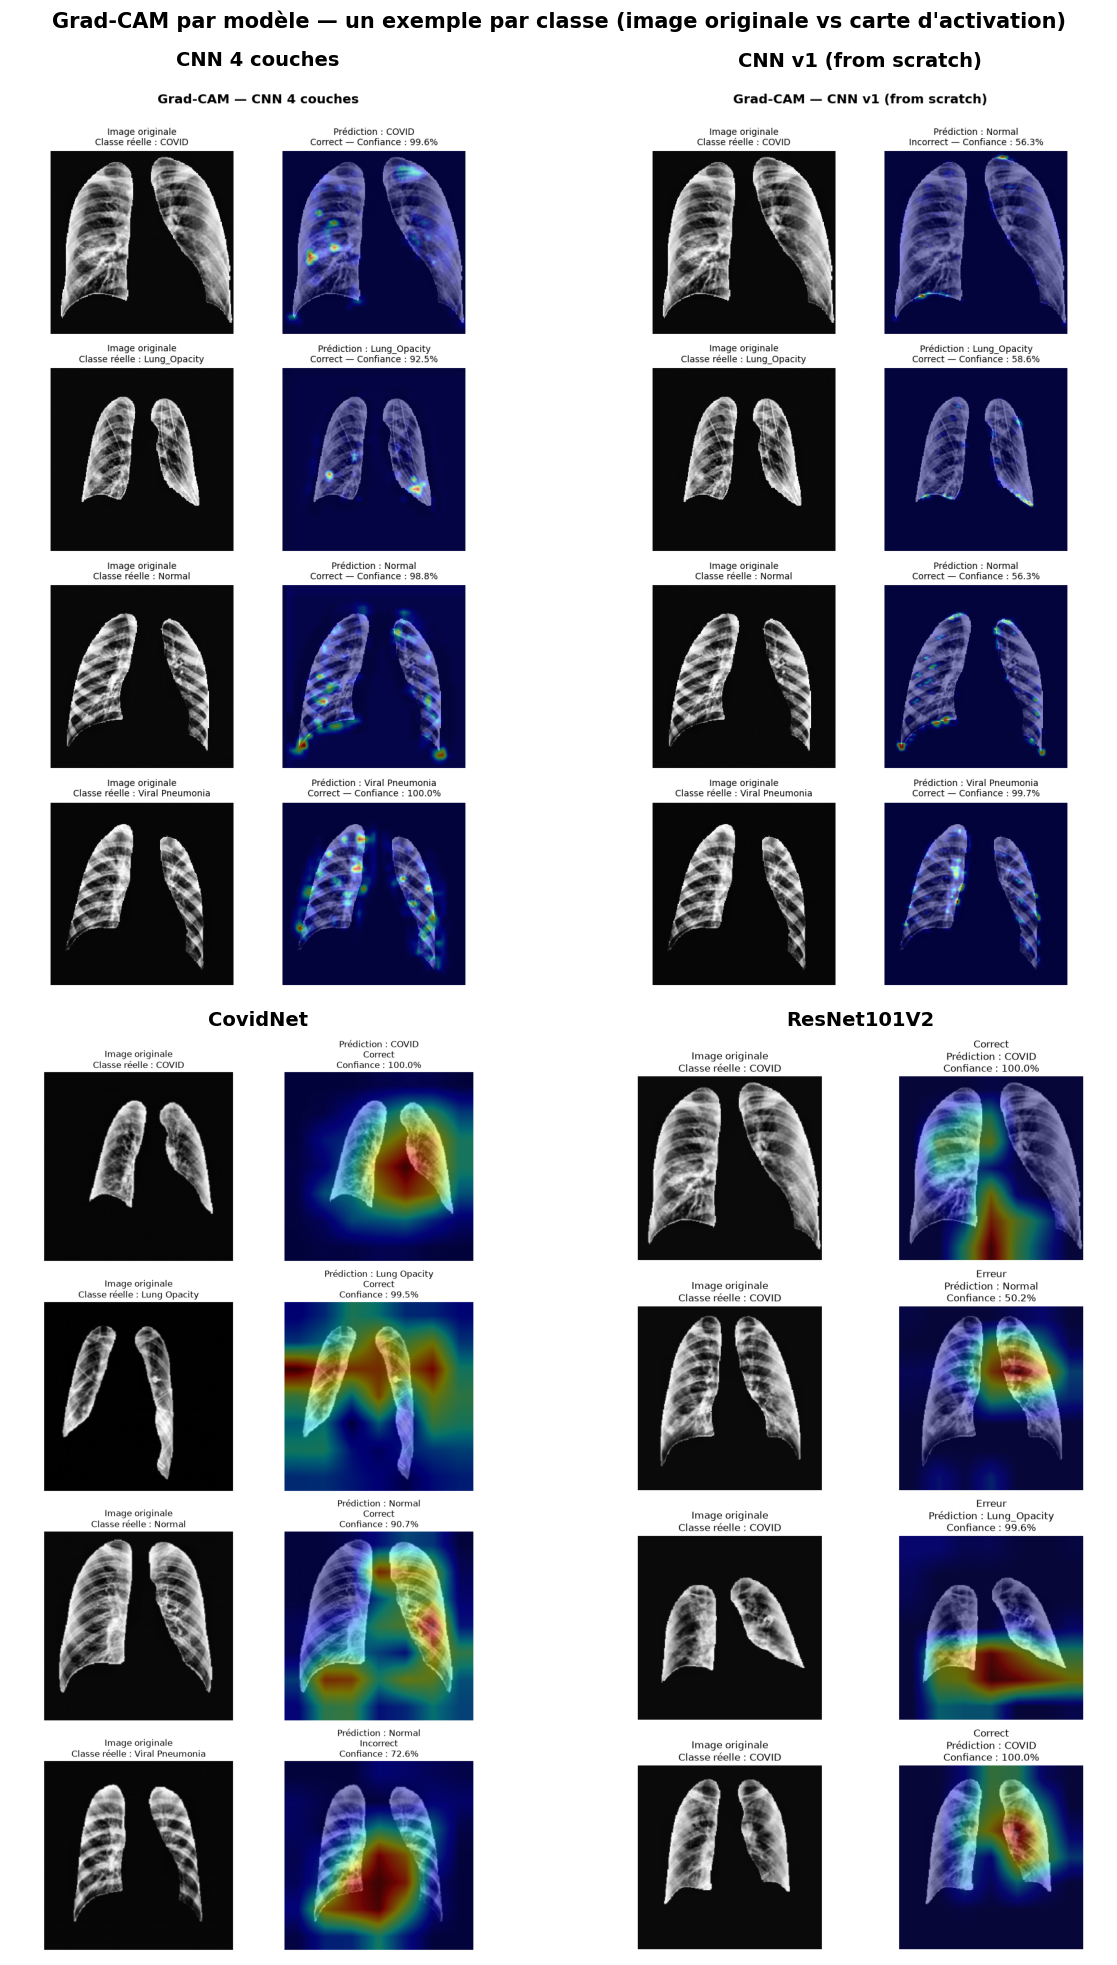

In [10]:
import matplotlib.image as mpimg

# (nom affiché, PNG dans reports/figures) — Grad-CAM disponibles
gradcams = [
    ("CNN 4 couches",               "gradcam_cnn256.png"),      # régénéré depuis cnn_256.keras
    ("CNN v1 (from scratch)", "gradcam_cnn_v1.png"),      # régénéré depuis cnn_v1_maxime.keras
    ("CovidNet",              "gradcam_covidnet.png"),    # extrait du notebook CovidNet_scratch_v2
    ("ResNet101V2",           "gradcam_resnet101.png"),   # extrait du notebook ResNet101V2
]
FIGDIR = "../reports/figures"

fig, axes = plt.subplots(2, 2, figsize=(13, 20))
for ax, (nom, f) in zip(axes.flat, gradcams):
    ax.imshow(mpimg.imread(f"{FIGDIR}/{f}"))
    ax.set_title(nom, fontsize=14, fontweight="bold")
    ax.axis("off")

fig.suptitle("Grad-CAM par modèle — un exemple par classe (image originale vs carte d'activation)",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.985])

os.makedirs(FIGDIR, exist_ok=True)
fig.savefig(f"{FIGDIR}/gradcam_planche.png", dpi=95, bbox_inches="tight")
print("planche sauvegardée -> reports/figures/gradcam_planche.png")
plt.show()

## Impact de la régularisation L2 et de la pondération des classes — CNN 4 couches

Comparaison des trois variantes du CNN 4 couches (256 filtres) : baseline, + régularisation L2, + L2 et pondération des classes (`class_weight`). Les prédictions sont chargées depuis les fichiers `.npy` sauvegardés dans `cnn256/`.

**Panneau gauche** : F1-score par classe pour chaque variante.  
**Panneau droit** : courbe Précision-Rappel sur la classe COVID uniquement — la plus sensible aux stratégies d'entraînement.

In [ ]:
from pathlib import Path

CLASSES_4 = ['COVID', 'Lung_Opacity', 'Normal', 'Viral\nPneumonia']
C1, C2, C3 = '#0072B2', '#E69F00', '#009E73'

MODELES_256 = {
    'CNN 4 couches\n(base)':   ('cnn256/y_true_test_cnn_256.npy',           'cnn256/y_prob_test_cnn_256.npy'),
    'CNN 4 couches\n+ L2':     ('cnn256/y_true_test_cnn_256_l2.npy',        'cnn256/y_prob_test_cnn_256_l2.npy'),
    'CNN 4 couches\n+ L2 + W': ('cnn256/y_true_test_cnn_256_l2_weight.npy', 'cnn256/y_prob_test_cnn_256_l2_weight.npy'),
}
COULEURS_256 = [C1, C2, C3]

data_256 = {}
for nom, (tp, pp) in MODELES_256.items():
    y_true = np.load(tp)
    y_prob = np.load(pp)
    y_pred = y_prob.argmax(axis=1)
    f1s = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2, 3])
    data_256[nom] = {'y_true': y_true, 'y_prob': y_prob, 'f1': f1s}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panneau 1 : F1 par classe
x = np.arange(4)
w = 0.22
for i, (nom, d) in enumerate(data_256.items()):
    bars = ax1.bar(x + (i - 1) * w, d['f1'], width=w - 0.02,
                   color=COULEURS_256[i], label=nom.replace('\n', ' '), zorder=3)
    for bar, v in zip(bars, d['f1']):
        ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.006,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, color='#222222')

ax1.set_xticks(x)
ax1.set_xticklabels(CLASSES_4, fontsize=10)
ax1.set_ylim(0, 1.12)
ax1.set_ylabel('F1-score', fontsize=10)
ax1.set_title('F1-score par classe', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8.5, frameon=False)
ax1.grid(axis='y', color='#eeeeee', zorder=0)
ax1.set_axisbelow(True)
for s in ['top', 'right']:
    ax1.spines[s].set_visible(False)

# Panneau 2 : Courbe PR — COVID uniquement
for i, (nom, d) in enumerate(data_256.items()):
    y_bin = label_binarize(d['y_true'], classes=[0, 1, 2, 3])
    prec, rec, _ = precision_recall_curve(y_bin[:, 0], d['y_prob'][:, 0])
    ap = average_precision_score(y_bin[:, 0], d['y_prob'][:, 0])
    ax2.plot(rec, prec, color=COULEURS_256[i], lw=2,
             label=f"{nom.replace(chr(10), ' ')} (AP={ap:.3f})")

ax2.set_xlabel('Rappel', fontsize=10)
ax2.set_ylabel('Précision', fontsize=10)
ax2.set_xlim(0, 1.02); ax2.set_ylim(0, 1.05)
ax2.set_title('Courbe PR — Classe COVID', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8.5, loc='lower left', frameon=True, framealpha=0.9)
ax2.grid(True, color='#eeeeee')
for s in ['top', 'right']:
    ax2.spines[s].set_visible(False)

fig.suptitle('Impact de la régularisation L2 et de la pondération des classes\n'
             'CNN 4 couches — jeu de test (2 084 images)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/cnn256_regularisation_compare.png', dpi=130, bbox_inches='tight')
plt.show()
print('figure sauvegardée -> reports/figures/cnn256_regularisation_compare.png')